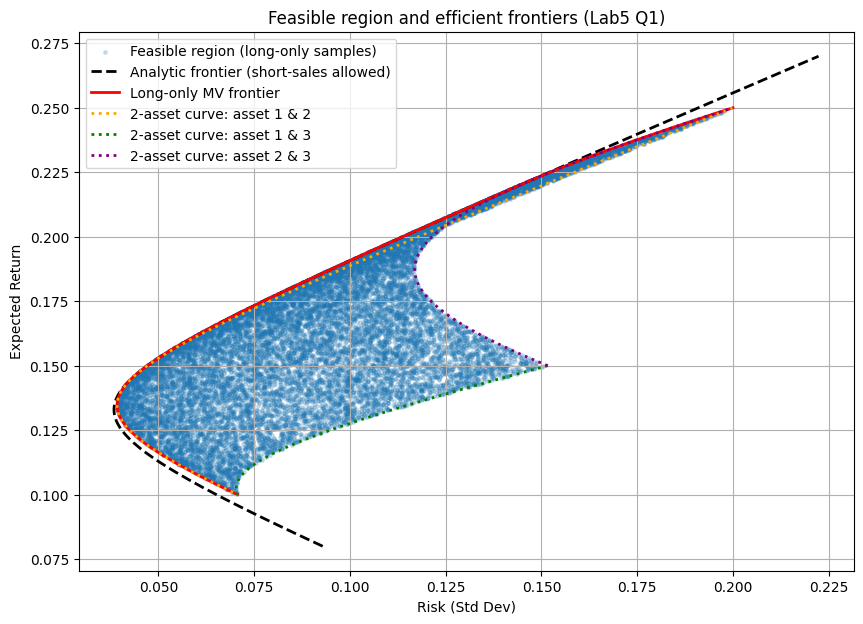

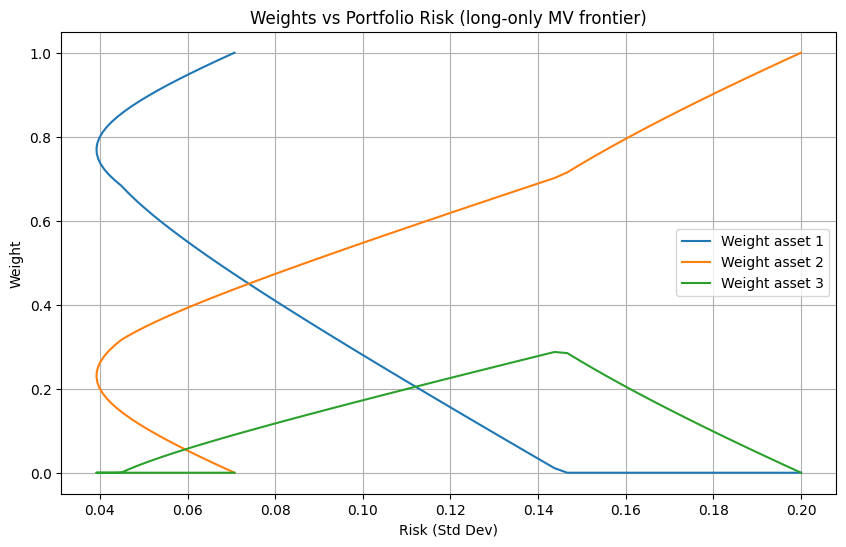

Ten sample long-only minimum-variance frontier portfolios:
        w1       w2       w3   Return   StdDev
0 1.000000 0.000000 0.000000 0.100000 0.070711
1 0.898734 0.101266 0.000000 0.115190 0.051270
2 0.784810 0.215190 0.000000 0.132278 0.039424
3 0.665584 0.326463 0.007953 0.149367 0.046538
4 0.506329 0.417722 0.075949 0.166456 0.065915
5 0.364769 0.498840 0.136391 0.181646 0.086795
6 0.205514 0.590099 0.204387 0.198734 0.111932
7 0.046259 0.681357 0.272384 0.215823 0.137895
8 0.000000 0.829114 0.170886 0.232911 0.166139
9 0.000000 1.000000 0.000000 0.250000 0.200000

Analytic unconstrained frontier weights satisfy:
w = alpha * C^{-1} * 1 + beta * C^{-1} * mu
where alpha and beta chosen to satisfy w'1 = 1 and w' mu = target_return.


In [1]:

"""
Lab 5 - Question 1
Computes efficient frontiers and related plots.

This uses the Lab 04 example mean returns and covariance matrix.
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import pandas as pd
import warnings

np.random.seed(42)
warnings.filterwarnings("ignore")

# ---------- Lab 04 data ----------
mu = np.array([0.10, 0.25, 0.15])    # expected returns
C = np.array([[0.005, -0.010, 0.004],
              [-0.010, 0.040, -0.002],
              [0.004, -0.002, 0.023]])  # covariance matrix

n = len(mu)
ones = np.ones(n)

# ---------- Helper functions ----------
def port_return(w):
    return float(w.dot(mu))

def port_variance(w):
    return float(w.dot(C).dot(w))

def port_std(w):
    return np.sqrt(port_variance(w))

# ---------- Analytic (unconstrained) efficient frontier ----------
invC = np.linalg.inv(C)
A = ones.dot(invC).dot(ones)
B = ones.dot(invC).dot(mu)
C_ = mu.dot(invC).dot(mu)
D = A*C_ - B**2

def analytical_weights(target_return):
    # w = alpha * invC * 1 + beta * invC * mu
    alpha = (C_ - B*target_return) / D
    beta  = (A*target_return - B) / D
    w = alpha * invC.dot(ones) + beta * invC.dot(mu)
    return w

# Build analytic frontier (allowing short sales)
target_returns = np.linspace(mu.min() - 0.02, mu.max() + 0.02, 200)
analytical_r = []
analytical_sigma = []
for r in target_returns:
    w = analytical_weights(r)
    analytical_r.append(port_return(w))
    analytical_sigma.append(port_std(w))
analytical_r = np.array(analytical_r)
analytical_sigma = np.array(analytical_sigma)

# ---------- Long-only constrained minimum variance frontier ----------
def min_variance_for_target_r(target_r, initial=None):
    if initial is None:
        initial = np.repeat(1.0/n, n)
    bounds = [(0.0, 1.0)] * n
    cons = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0},
            {'type': 'eq', 'fun': lambda w: w.dot(mu) - target_r})
    res = minimize(lambda w: w.dot(C).dot(w),
                   initial,
                   method='SLSQP',
                   bounds=bounds,
                   constraints=cons,
                   options={'ftol':1e-12, 'maxiter':500})
    if not res.success:
        return None
    return res.x

min_long_return = mu.min()       # for long-only feasible returns min asset return
max_long_return = mu.max()       # for long-only feasible returns max asset return
constrained_returns = np.linspace(min_long_return, max_long_return, 80)

constrained_ws = []
constrained_r = []
constrained_sigma = []
for r in constrained_returns:
    w = min_variance_for_target_r(r)
    if w is None:
        continue
    constrained_ws.append(w)
    constrained_r.append(port_return(w))
    constrained_sigma.append(port_std(w))
constrained_ws = np.array(constrained_ws)
constrained_r = np.array(constrained_r)
constrained_sigma = np.array(constrained_sigma)

# ---------- Feasible region via Monte Carlo (long-only) ----------
def random_long_only_weights(n):
    x = np.random.gamma(1.0, 1.0, size=n)
    return x/x.sum()

mc = 20000
mc_r = np.empty(mc)
mc_sigma = np.empty(mc)
for i in range(mc):
    w = random_long_only_weights(n)
    mc_r[i] = port_return(w)
    mc_sigma[i] = port_std(w)

# ---------- Two-asset curves ----------
pairs = [(0,1), (0,2), (1,2)]
pair_frontiers = {}
t_grid = np.linspace(0,1,200)
for (i,j) in pairs:
    r_list = []
    sigma_list = []
    for t in t_grid:
        w = np.zeros(n)
        w[i] = t
        w[j] = 1-t
        r_list.append(port_return(w))
        sigma_list.append(port_std(w))
    pair_frontiers[(i,j)] = (np.array(r_list), np.array(sigma_list))

# ---------- Plots ----------
plt.figure(figsize=(10,7))
plt.scatter(mc_sigma, mc_r, s=6, alpha=0.2, label='Feasible region (long-only samples)')
plt.plot(analytical_sigma, analytical_r, 'k--', lw=2, label='Analytic frontier (short-sales allowed)')
if len(constrained_sigma) > 0:
    plt.plot(constrained_sigma, constrained_r, 'r-', lw=2, label='Long-only MV frontier')
colors = ['orange','green','purple']
for idx, key in enumerate(pair_frontiers):
    r_list, sigma_list = pair_frontiers[key]
    plt.plot(sigma_list, r_list, color=colors[idx], linestyle=':', lw=2,
             label=f'2-asset curve: asset {key[0]+1} & {key[1]+1}')
plt.xlabel('Risk (Std Dev)')
plt.ylabel('Expected Return')
plt.title('Feasible region and efficient frontiers (Lab5 Q1)')
plt.legend()
plt.grid(True)
plt.show()

# weights vs risk along long-only frontier
if len(constrained_ws) > 0:
    plt.figure(figsize=(10,6))
    for k in range(n):
        plt.plot(constrained_sigma, constrained_ws[:,k], label=f'Weight asset {k+1}')
    plt.xlabel('Risk (Std Dev)')
    plt.ylabel('Weight')
    plt.title('Weights vs Portfolio Risk (long-only MV frontier)')
    plt.legend()
    plt.grid(True)
    plt.show()

# Print sample frontier portfolios (10 samples)
if len(constrained_sigma) > 0:
    idxs = np.linspace(0, len(constrained_sigma)-1, 10, dtype=int)
    rows = []
    for idx in idxs:
        w = constrained_ws[idx]
        rows.append({'w1':w[0], 'w2':w[1], 'w3':w[2],
                     'Return': constrained_r[idx], 'StdDev': constrained_sigma[idx]})
    df = pd.DataFrame(rows)
    pd.set_option('display.float_format', lambda x: f'{x:.6f}')
    print("Ten sample long-only minimum-variance frontier portfolios:")
    print(df)
else:
    print("No feasible long-only frontier points were found.")

# Print analytic formula reminder
print("\nAnalytic unconstrained frontier weights satisfy:")
print("w = alpha * C^{-1} * 1 + beta * C^{-1} * mu")
print("where alpha and beta chosen to satisfy w'1 = 1 and w' mu = target_return.")


Saved nsedata1.xlsx and bsedata1.xlsx
Computing CAPM betas for NSE...
Computing CAPM betas for BSE...


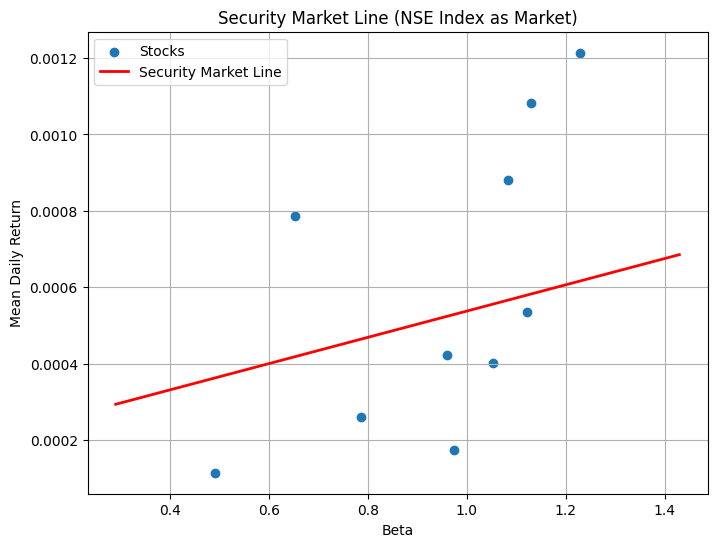

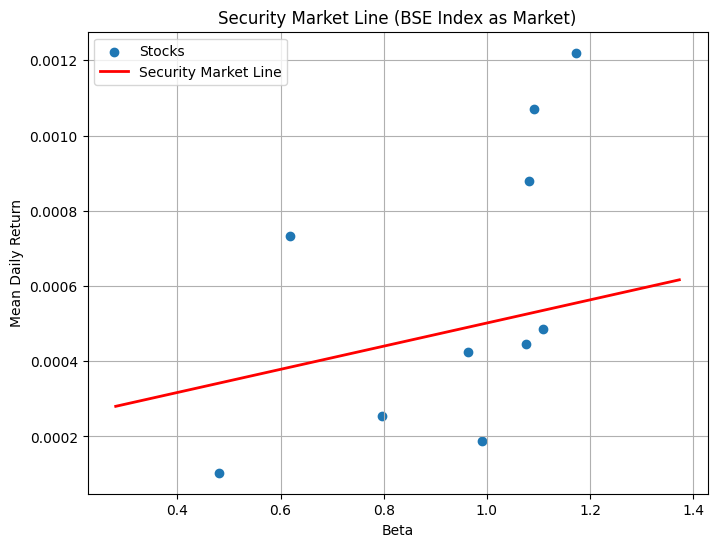


CAPM Betas – NSE:
                  Beta  Mean_Return
Stock                              
HINDUNILVR.NS 0.490845     0.000115
ITC.NS        0.652771     0.000785
TCS.NS        0.786284     0.000260
INFY.NS       0.960370     0.000423
KOTAKBANK.NS  0.974051     0.000173
HDFCBANK.NS   1.054006     0.000401
ICICIBANK.NS  1.083131     0.000880
RELIANCE.NS   1.120729     0.000536
LT.NS         1.130248     0.001081
SBIN.NS       1.229507     0.001214

CAPM Betas – BSE:
                  Beta  Mean_Return
Stock                              
HINDUNILVR.BO 0.480380     0.000103
ITC.BO        0.618392     0.000733
TCS.BO        0.796425     0.000255
INFY.BO       0.964069     0.000425
KOTAKBANK.BO  0.990343     0.000187
HDFCBANK.BO   1.076003     0.000445
ICICIBANK.BO  1.082621     0.000880
LT.BO         1.090913     0.001070
RELIANCE.BO   1.108920     0.000485
SBIN.BO       1.173359     0.001220

DONE ✔
Generated files:
nsedata1.xlsx, bsedata1.xlsx
nse_betas.xlsx, bse_betas.xlsx


In [9]:
# ===================== LAB 5 : QUESTION 2 =====================
# CAPM Beta computation + Security Market Line (SML)
# =============================================================

import pandas as pd
import numpy as np
import yfinance as yf
import statsmodels.api as sm
import matplotlib.pyplot as plt

# ---------------- PARAMETERS ----------------
START_DATE = "2021-01-01"
END_DATE = "2025-12-31"
RISK_FREE_RATE_ANNUAL = 0.05
TRADING_DAYS = 252

# Market indices
NSE_INDEX = "^NSEI"     # NIFTY 50
BSE_INDEX = "^BSESN"   # SENSEX

# Stable large-cap stocks
NSE_STOCKS = [
    "RELIANCE.NS", "TCS.NS", "INFY.NS", "HDFCBANK.NS", "ICICIBANK.NS",
    "HINDUNILVR.NS", "ITC.NS", "LT.NS", "SBIN.NS", "KOTAKBANK.NS"
]

BSE_STOCKS = [
    "RELIANCE.BO", "TCS.BO", "INFY.BO", "HDFCBANK.BO", "ICICIBANK.BO",
    "HINDUNILVR.BO", "ITC.BO", "LT.BO", "SBIN.BO", "KOTAKBANK.BO"
]

# ---------------- FUNCTIONS ----------------
def download_prices(tickers):
    """Download prices, using Adj Close if available"""
    data = yf.download(tickers, start=START_DATE, end=END_DATE, progress=False)

    if data.empty:
        return pd.DataFrame()

    if isinstance(data.columns, pd.MultiIndex):
        prices = data["Adj Close"] if "Adj Close" in data.columns.levels[0] else data["Close"]
    else:
        prices = data["Adj Close"] if "Adj Close" in data else data["Close"]

    if isinstance(prices, pd.Series):
        prices = prices.to_frame()

    return prices.dropna(how="all")


def compute_returns(price_df):
    """Daily simple returns"""
    return price_df.pct_change().dropna()


def compute_betas_and_means(returns_df, market_col, rf_daily):
    """
    Computes:
    - Beta (CAPM)
    - Mean return of stock
    """
    results = []

    market_excess = returns_df[market_col] - rf_daily

    for stock in returns_df.columns:
        if stock == market_col:
            continue

        stock_excess = returns_df[stock] - rf_daily
        df = pd.concat([stock_excess, market_excess], axis=1).dropna()

        if len(df) < 60:
            continue

        X = sm.add_constant(df.iloc[:, 1])
        y = df.iloc[:, 0]

        model = sm.OLS(y, X).fit()

        results.append({
            "Stock": stock,
            "Beta": model.params[1],
            "Mean_Return": returns_df[stock].mean()
        })

    return pd.DataFrame(results).set_index("Stock")


def plot_sml(beta_df, market_mean, title, rf_daily):
    """
    Plot Security Market Line
    """
    if beta_df.empty:
        print(f"No SML plot for {title}")
        return

    betas = beta_df["Beta"]
    mean_returns = beta_df["Mean_Return"]

    x = np.linspace(betas.min() - 0.2, betas.max() + 0.2, 100)
    sml = rf_daily + x * (market_mean - rf_daily)

    plt.figure(figsize=(8,6))
    plt.scatter(betas, mean_returns, label="Stocks")
    plt.plot(x, sml, color="red", linewidth=2, label="Security Market Line")
    plt.xlabel("Beta")
    plt.ylabel("Mean Daily Return")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

# ---------------- DOWNLOAD DATA ----------------
print("Downloading NSE data...")
nse_index_prices = download_prices(NSE_INDEX).rename(columns={NSE_INDEX: "NSE_Index"})
nse_stock_prices = download_prices(NSE_STOCKS)

print("Downloading BSE data...")
bse_index_prices = download_prices(BSE_INDEX).rename(columns={BSE_INDEX: "BSE_Index"})
bse_stock_prices = download_prices(BSE_STOCKS)

# ---------------- SAVE EXCEL FILES ----------------
nse_prices = pd.concat([nse_index_prices, nse_stock_prices], axis=1)
bse_prices = pd.concat([bse_index_prices, bse_stock_prices], axis=1)

nse_prices.to_excel("nsedata1.xlsx")
bse_prices.to_excel("bsedata1.xlsx")

print("Saved nsedata1.xlsx and bsedata1.xlsx")

# ---------------- RETURNS ----------------
nse_returns = compute_returns(nse_prices)
bse_returns = compute_returns(bse_prices)

rf_daily = (1 + RISK_FREE_RATE_ANNUAL) ** (1 / TRADING_DAYS) - 1

# ---------------- CAPM BETAS ----------------
print("Computing CAPM betas for NSE...")
nse_beta_df = compute_betas_and_means(nse_returns, "NSE_Index", rf_daily)

print("Computing CAPM betas for BSE...")
bse_beta_df = compute_betas_and_means(bse_returns, "BSE_Index", rf_daily)

# Save betas
nse_beta_df.to_excel("nse_betas.xlsx")
bse_beta_df.to_excel("bse_betas.xlsx")

# ---------------- SML PLOTS ----------------
plot_sml(
    nse_beta_df,
    nse_returns["NSE_Index"].mean(),
    "Security Market Line (NSE Index as Market)",
    rf_daily
)

plot_sml(
    bse_beta_df,
    bse_returns["BSE_Index"].mean(),
    "Security Market Line (BSE Index as Market)",
    rf_daily
)

# ---------------- OUTPUT ----------------
print("\nCAPM Betas – NSE:")
print(nse_beta_df.sort_values("Beta"))

print("\nCAPM Betas – BSE:")
print(bse_beta_df.sort_values("Beta"))

print("\nDONE ✔")
print("Generated files:")
print("nsedata1.xlsx, bsedata1.xlsx")
print("nse_betas.xlsx, bse_betas.xlsx")
